# 06 — Esperimento supplementare: l'orizzonte di previsione

La pipeline principale prevede lo State of Health del **ciclo successivo**, e su quel
compito nessun modello neurale batte la baseline di persistenza. Questo notebook verifica
l'ipotesi che spiega quel risultato.

**L'ipotesi.** A un ciclo di distanza il SoH cambia di circa due millesimi, mentre il
rumore di misura è dello stesso ordine: il bersaglio è quasi tutto rumore, e ripetere
l'ultimo valore osservato è già una previsione ottimale. Allungando l'orizzonte, la
componente sistematica del degrado cresce linearmente con il numero di cicli mentre il
rumore resta costante: il rapporto fra i due migliora, e a un certo punto un modello che
ha imparato la forma del degrado deve superare chi si limita a ripetere.

**Cosa misura questo notebook.** Lo stesso modello, addestrato su orizzonti crescenti, e
il punto in cui supera la baseline — se esiste.

**Input:** `data/processed/battery_cycles.csv`, prodotto dal notebook 01.

**Output**

| percorso | contenuto |
|---|---|
| `results/tables/06_orizzonte_metriche.csv` | metriche per orizzonte, modello e insieme |
| `results/tables/06_orizzonte_punto_di_pareggio.csv` | dove il modello raggiunge la baseline |
| `results/figures/06_orizzonte_*.png` | curve di errore e skill score |

Il notebook è indipendente dal 02 e dal 03: ricostruisce le sequenze da sé, perché deve
farlo a orizzonti diversi. Le convenzioni — variabili, suddivisione, normalizzazione,
bersaglio — sono le stesse, e vengono ridichiarate qui in modo esplicito.


## 1. Configurazione


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    pass


def find_project_root():
    candidate_paths = [
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/drive/My Drive/SoH_Neural_Tracker"),
        Path.cwd(), *Path.cwd().parents,
    ]
    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
for cartella in [TABLES_DIR, FIGURES_DIR]:
    cartella.mkdir(parents=True, exist_ok=True)

print("Radice del progetto:", PROJECT_ROOT)


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker


## 2. Convenzioni, identiche a quelle della pipeline principale

Variabili di ingresso, suddivisione e ampiezza della finestra sono quelle del notebook 02.
L'unica cosa che cambia da un esperimento all'altro è l'orizzonte.

Gli orizzonti scelti coprono tre regimi: pochi cicli, dove ci si attende che la
persistenza domini; alcune decine, dove dovrebbe avvenire il passaggio; e cinquanta cicli,
dove il degrado accumulato è confrontabile con l'intero intervallo di SoH osservato. Sopra
i cinquanta il numero di finestre disponibili crolla, perché ogni finestra consuma
`WINDOW_SIZE + orizzonte` cicli contigui.


In [2]:
WINDOW_SIZE = 10
ORIZZONTI = [1, 5, 10, 20, 30, 50]
LIMITE_SCOSTAMENTO = 5.0

VARIABILI = [
    "soh_feature",
    "voltage_mean_rel", "voltage_min_rel", "voltage_max_rel", "voltage_std_rel",
    "temperature_mean_rise_rel", "temperature_max_rise_rel", "temperature_std_rel",
    "discharge_time_rel", "num_measurements_rel",
]

SPLIT = {
    "train":      ["B0005_p1", "B0006_p1"],
    "validation": ["B0007_p1"],
    "test_id":    ["B0018_p1", "B0042_p1", "B0043_p1"],
    "test_ood":   ["B0029_p1", "B0030_p1", "B0031_p1", "B0032_p1",
                   "B0042_p2", "B0043_p2"],
}
INSIEMI = list(SPLIT)

percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"
assert percorso_cicli.exists(), "manca battery_cycles.csv: esegui prima 01_preprocessing"

df = pd.read_csv(percorso_cicli)
df["soh_feature"] = df["soh"]

assenti = [c for c in VARIABILI if c not in df.columns]
assert not assenti, f"colonne assenti nel dataset: {assenti}"

print(f"Cicli: {len(df)}   validi: {int(df.is_valid.sum())}")
print(f"Orizzonti da provare: {ORIZZONTI}")


Cicli: 1020   validi: 926
Orizzonti da provare: [1, 5, 10, 20, 30, 50]


## 3. Costruzione delle sequenze a orizzonte variabile

La finestra copre sempre dieci cicli; cambia quanto lontano si trova il ciclo da prevedere.
Come nella pipeline principale, la finestra e il bersaglio devono appartenere allo stesso
tratto di cicli consecutivi e validi dello stesso blocco di protocollo: una finestra che
scavalcasse un ciclo scartato descriverebbe un'evoluzione mai avvenuta, e a orizzonte
lungo il rischio è maggiore perché il tratto richiesto è più lungo.

La normalizzazione si stima sulle sole celle di addestramento e non dipende
dall'orizzonte: viene quindi calcolata una volta sola.


In [3]:
from sklearn.preprocessing import StandardScaler

da_normalizzare = [c for c in VARIABILI if c != "soh_feature"]

train_valido = df[df.protocol_block.isin(SPLIT["train"]) & df.is_valid]
scaler = StandardScaler().fit(train_valido[da_normalizzare])

df_scalato = df.copy()
df_scalato[da_normalizzare] = np.clip(
    scaler.transform(df[da_normalizzare]), -LIMITE_SCOSTAMENTO, LIMITE_SCOSTAMENTO)


def costruisci_finestre(blocchi, orizzonte):
    """Finestre di WINDOW_SIZE cicli e bersaglio a `orizzonte` cicli di distanza.

    Il tratto contiguo viene ricavato qui dalla numerazione dei cicli validi, come nel
    notebook 02: la contiguità va verificata dove le sequenze nascono.
    """
    X, y, ultimo, provenienza = [], [], [], []

    for blocco in blocchi:
        gruppo = df_scalato[(df_scalato.protocol_block == blocco) & df_scalato.is_valid]
        gruppo = gruppo.sort_values("discharge_cycle")
        numerazione = gruppo.discharge_cycle.to_numpy()

        apre = np.ones(len(gruppo), dtype=bool)
        apre[1:] = np.diff(numerazione) != 1

        for _, tratto in gruppo.groupby(np.cumsum(apre)):
            valori = tratto[VARIABILI].to_numpy()
            soh = tratto["soh"].to_numpy()
            for i in range(len(tratto) - WINDOW_SIZE - orizzonte + 1):
                fine = i + WINDOW_SIZE - 1
                X.append(valori[i:i + WINDOW_SIZE])
                y.append(soh[fine + orizzonte])
                ultimo.append(soh[fine])
                provenienza.append(blocco)

    return {
        "X": np.asarray(X, dtype="float32"),
        "y": np.asarray(y, dtype="float32"),
        "soh_ultimo": np.asarray(ultimo, dtype="float32"),
        "protocol_block": np.asarray(provenienza),
    }


disponibilita = []
for orizzonte in ORIZZONTI:
    riga = {"orizzonte": orizzonte}
    for nome, blocchi in SPLIT.items():
        riga[nome] = len(costruisci_finestre(blocchi, orizzonte)["y"])
    disponibilita.append(riga)

disponibilita = pd.DataFrame(disponibilita)
display(disponibilita)

print("\nOgni finestra consuma WINDOW_SIZE + orizzonte cicli contigui: allungando")
print("l'orizzonte il numero di esempi cala, ed è il costo dell'esperimento.")


,orizzonte,train,validation,test_id,test_ood
0,1,316,158,172,150
1,5,308,154,160,126
2,10,298,149,145,96
3,20,278,139,115,44
4,30,258,129,93,4
5,50,218,109,73,0



Ogni finestra consuma WINDOW_SIZE + orizzonte cicli contigui: allungando
l'orizzonte il numero di esempi cala, ed è il costo dell'esperimento.


In [4]:
FINESTRE_MINIME = 20

# Un orizzonte è utilizzabile se addestramento, validazione e test in distribuzione
# hanno abbastanza finestre. Il test fuori distribuzione è fatto di blocchi corti — 40
# cicli le celle a 43 °C, 25 i tratti freddi — e a orizzonte lungo si svuota per primo:
# viene quindi valutato solo dove esiste, invece di far cadere l'intero orizzonte.
tabella_disponibilita = disponibilita.set_index("orizzonte")
NECESSARI = ["train", "validation", "test_id"]

ORIZZONTI_UTILI = [o for o in ORIZZONTI
                   if all(tabella_disponibilita.loc[o, nome] >= FINESTRE_MINIME
                          for nome in NECESSARI)]
INSIEMI_PER_ORIZZONTE = {
    o: [nome for nome in INSIEMI
        if tabella_disponibilita.loc[o, nome] >= FINESTRE_MINIME]
    for o in ORIZZONTI_UTILI
}

scartati = sorted(set(ORIZZONTI) - set(ORIZZONTI_UTILI))
if scartati:
    print("Orizzonti esclusi del tutto:", scartati)
print("Orizzonti valutati:", ORIZZONTI_UTILI)
for o in ORIZZONTI_UTILI:
    mancanti = sorted(set(INSIEMI) - set(INSIEMI_PER_ORIZZONTE[o]))
    if mancanti:
        print(f"  orizzonte {o:3d}: non valutato su {', '.join(mancanti)} "
              f"(meno di {FINESTRE_MINIME} finestre)")


Orizzonti valutati: [1, 5, 10, 20, 30, 50]
  orizzonte  30: non valutato su test_ood (meno di 20 finestre)
  orizzonte  50: non valutato su test_ood (meno di 20 finestre)


## 4. Le baseline, ricalcolate a ogni orizzonte

**Persistenza:** ripete l'ultimo SoH osservato. Il suo errore cresce con l'orizzonte,
perché il degrado accumulato fra la fine della finestra e il bersaglio cresce.

**Retta sulla finestra:** interpola i dieci SoH osservati e prolunga fino al bersaglio. A
orizzonte 1 abbiamo visto che è peggiore della persistenza, perché stimare una pendenza da
dieci punti rumorosi costa più varianza di quanta distorsione elimini. Allungando
l'orizzonte il bilancio dovrebbe rovesciarsi, ed è la stessa ragione per cui ci si attende
che i modelli neurali migliorino.

Il confronto fra le due baseline è quindi informativo di per sé: dice se la tendenza
diventa utile prima ancora di chiamare in causa una rete.


In [5]:
def rmse(vero, previsto):
    return float(np.sqrt(np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)))


def skill_score(vero, previsto, baseline):
    mse_modello = np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)
    mse_baseline = np.mean((np.asarray(baseline) - np.asarray(vero)) ** 2)
    return float(1.0 - mse_modello / mse_baseline) if mse_baseline else np.nan


passi = np.arange(WINDOW_SIZE)
indice_soh = VARIABILI.index("soh_feature")


def estrapola_retta(X, orizzonte):
    """Retta ai minimi quadrati sui SoH della finestra, prolungata fino al bersaglio."""
    finestre_soh = X[:, :, indice_soh]
    pendenza, intercetta = np.polyfit(passi, finestre_soh.T, 1)
    return pendenza * (passi[-1] + orizzonte) + intercetta


## 5. Il modello

Una sola architettura, la migliore emersa dal confronto del notebook 03, addestrata da
capo per ogni orizzonte. Confrontare quattro architetture su sei orizzonti moltiplicherebbe
il costo senza aggiungere nulla: la domanda qui è come cambia il compito, non quale rete
lo affronta meglio.

Il bersaglio resta la **variazione** rispetto all'ultimo ciclo osservato. A orizzonte lungo
la scelta è ancora più naturale che a orizzonte uno: la variazione cresce e diventa la
parte dominante di ciò che va previsto, mentre il livello resta noto dagli ingressi.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

ARCHITETTURA = "GRU"
UNITA, UNITA_DENSA, DROPOUT = 64, 32, 0.2
SEMI = [0, 1, 2]
EPOCHE, BATCH_SIZE, PAZIENZA = 150, 32, 20


def costruisci(forma, bias_iniziale):
    ingresso = layers.Input(shape=forma)
    strato = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM,
              "GRU": layers.GRU}[ARCHITETTURA]
    x = strato(UNITA)(ingresso)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(UNITA_DENSA, activation="relu")(x)
    uscita = layers.Dense(
        1, bias_initializer=tf.keras.initializers.Constant(bias_iniziale))(x)
    return models.Model(ingresso, uscita)


def valuta_orizzonte(orizzonte):
    """Addestra su un orizzonte e restituisce le metriche di modello e baseline."""
    valutabili = INSIEMI_PER_ORIZZONTE[orizzonte]
    dati = {nome: costruisci_finestre(SPLIT[nome], orizzonte) for nome in valutabili}
    variazione = {nome: dati[nome]["y"] - dati[nome]["soh_ultimo"] for nome in valutabili}

    righe = []
    for nome in valutabili:
        d = dati[nome]
        righe.append({"orizzonte": orizzonte, "modello": "Baseline persistenza",
                      "insieme": nome, "seme": -1, "n_finestre": len(d["y"]),
                      "RMSE": rmse(d["y"], d["soh_ultimo"]), "SS": 0.0})
        retta = estrapola_retta(d["X"], orizzonte)
        righe.append({"orizzonte": orizzonte, "modello": "Baseline retta",
                      "insieme": nome, "seme": -1, "n_finestre": len(d["y"]),
                      "RMSE": rmse(d["y"], retta),
                      "SS": skill_score(d["y"], retta, d["soh_ultimo"])})

    for seme in SEMI:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seme)

        modello = costruisci(dati["train"]["X"].shape[1:],
                             float(variazione["train"].mean()))
        modello.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        modello.fit(dati["train"]["X"], variazione["train"],
                    validation_data=(dati["validation"]["X"], variazione["validation"]),
                    epochs=EPOCHE, batch_size=BATCH_SIZE, verbose=0,
                    callbacks=[callbacks.EarlyStopping(monitor="val_loss",
                                                       patience=PAZIENZA,
                                                       restore_best_weights=True)])

        for nome in valutabili:
            d = dati[nome]
            previsto = modello.predict(d["X"], verbose=0).reshape(-1) + d["soh_ultimo"]
            righe.append({"orizzonte": orizzonte, "modello": ARCHITETTURA,
                          "insieme": nome, "seme": seme, "n_finestre": len(d["y"]),
                          "RMSE": rmse(d["y"], previsto),
                          "SS": skill_score(d["y"], previsto, d["soh_ultimo"])})

    return pd.DataFrame(righe)


In [7]:
risultati = []
for orizzonte in ORIZZONTI_UTILI:
    tabella = valuta_orizzonte(orizzonte)
    risultati.append(tabella)

    sotto = tabella[tabella.insieme == "test_id"]
    base = float(sotto[sotto.modello == "Baseline persistenza"].RMSE.iloc[0])
    modello_rmse = float(sotto[sotto.modello == ARCHITETTURA].RMSE.median())
    esito = "modello" if modello_rmse < base else "persistenza"
    print(f"orizzonte {orizzonte:3d}   persistenza {base:.5f}   "
          f"{ARCHITETTURA} {modello_rmse:.5f}   vince: {esito}")

metriche = pd.concat(risultati, ignore_index=True)
metriche.to_csv(TABLES_DIR / "06_orizzonte_metriche.csv", index=False)


orizzonte   1   persistenza 0.01103   GRU 0.02177   vince: persistenza
orizzonte   5   persistenza 0.02072   GRU 0.04654   vince: persistenza
orizzonte  10   persistenza 0.03114   GRU 0.02858   vince: modello
orizzonte  20   persistenza 0.05034   GRU 0.04985   vince: modello
orizzonte  30   persistenza 0.06672   GRU 0.03634   vince: modello
orizzonte  50   persistenza 0.11299   GRU 0.04054   vince: modello


## 6. Il punto di pareggio

Per ogni insieme di prova si cerca il primo orizzonte in cui l'errore mediano del modello
scende sotto quello della persistenza. È il punto oltre il quale il deep learning aggiunge
qualcosa.


In [8]:
riepilogo = (metriche.groupby(["orizzonte", "modello", "insieme"])
             .agg(RMSE=("RMSE", "median"), SS=("SS", "median"),
                  n_finestre=("n_finestre", "first"))
             .reset_index())

righe_pareggio = []
for insieme in ["validation", "test_id", "test_ood"]:
    sotto = riepilogo[riepilogo.insieme == insieme]
    if not len(sotto):
        continue
    base = sotto[sotto.modello == "Baseline persistenza"].set_index("orizzonte").RMSE
    for nome_modello in [ARCHITETTURA, "Baseline retta"]:
        curva = sotto[sotto.modello == nome_modello].set_index("orizzonte").RMSE
        vincenti = [o for o in curva.index if o in base.index and curva[o] < base[o]]
        righe_pareggio.append({
            "insieme": insieme, "modello": nome_modello,
            "primo_orizzonte_vincente": min(vincenti) if vincenti else None,
            "orizzonti_vincenti": len(vincenti),
            "orizzonti_provati": len(curva),
        })

pareggio = pd.DataFrame(righe_pareggio)
display(pareggio)
pareggio.to_csv(TABLES_DIR / "06_orizzonte_punto_di_pareggio.csv", index=False)
riepilogo.to_csv(TABLES_DIR / "06_orizzonte_riepilogo.csv", index=False)


,insieme,modello,primo_orizzonte_vincente,orizzonti_vincenti,orizzonti_provati
0,validation,GRU,10.0,4,6
1,validation,Baseline retta,10.0,4,6
2,test_id,GRU,10.0,4,6
3,test_id,Baseline retta,NaN,0,6
4,test_ood,GRU,20.0,1,4
5,test_ood,Baseline retta,1.0,4,4


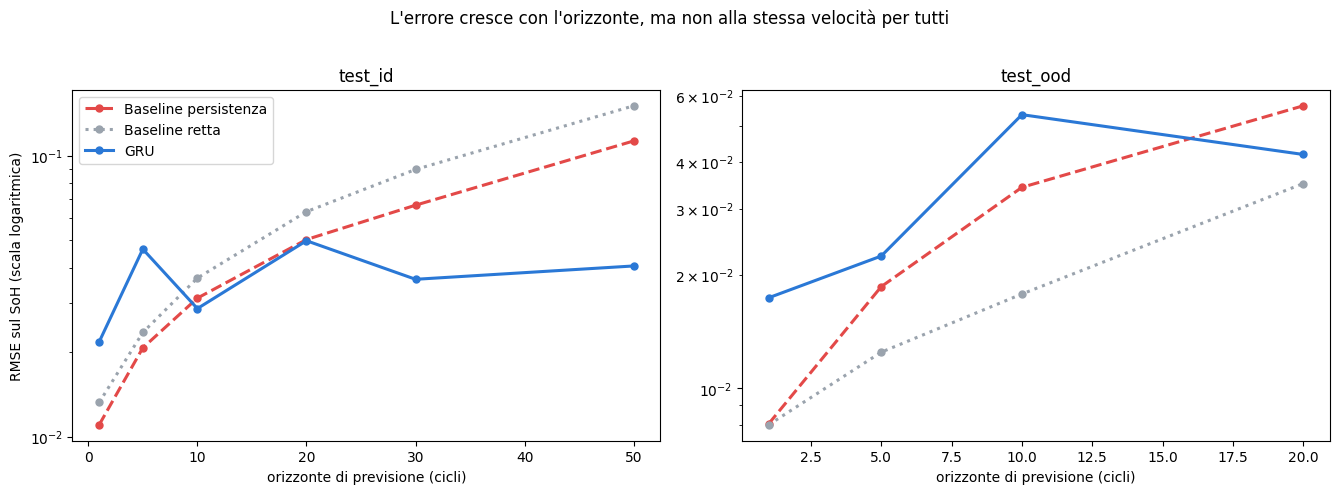

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

for ax, insieme in zip(axes, ["test_id", "test_ood"]):
    sotto = riepilogo[riepilogo.insieme == insieme]
    for nome_modello, colore, stile in [("Baseline persistenza", "#e34948", "--"),
                                        ("Baseline retta", "#9aa3ad", ":"),
                                        (ARCHITETTURA, "#2a78d6", "-")]:
        curva = sotto[sotto.modello == nome_modello].sort_values("orizzonte")
        ax.plot(curva.orizzonte, curva.RMSE, stile, color=colore, lw=2.2,
                marker="o", ms=5, label=nome_modello)
    ax.set_xlabel("orizzonte di previsione (cicli)")
    ax.set_title(insieme)
    ax.set_yscale("log")

axes[0].set_ylabel("RMSE sul SoH (scala logaritmica)")
axes[0].legend()
fig.suptitle("L'errore cresce con l'orizzonte, ma non alla stessa velocità per tutti",
             y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_orizzonte_rmse.png", dpi=200, bbox_inches="tight")
plt.show()


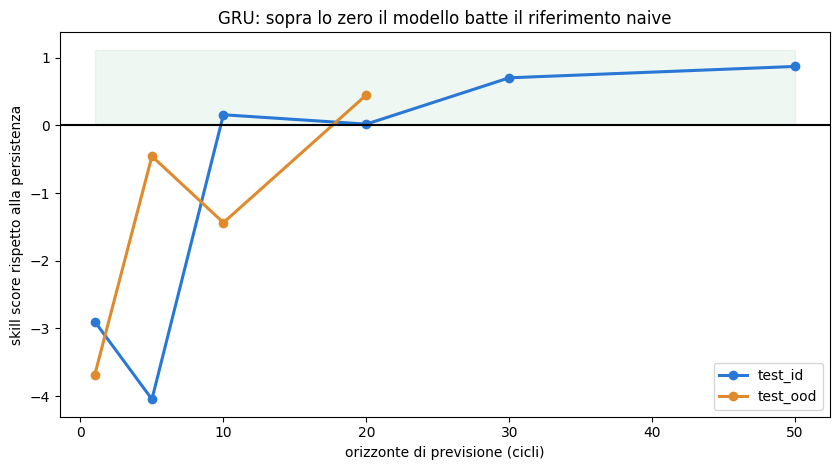

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

for insieme, colore in [("test_id", "#2a78d6"), ("test_ood", "#e08a2e")]:
    curva = (riepilogo[(riepilogo.insieme == insieme)
                       & (riepilogo.modello == ARCHITETTURA)]
             .sort_values("orizzonte"))
    if not len(curva):
        continue
    ax.plot(curva.orizzonte, curva.SS, "-o", color=colore, lw=2.2, ms=6, label=insieme)

ax.axhline(0, color="black", lw=1.5)
ax.fill_between([min(ORIZZONTI_UTILI), max(ORIZZONTI_UTILI)], 0, max(ax.get_ylim()[1], 0.01),
                color="#2a9d5c", alpha=0.08)
ax.set_xlabel("orizzonte di previsione (cicli)")
ax.set_ylabel("skill score rispetto alla persistenza")
ax.set_title(f"{ARCHITETTURA}: sopra lo zero il modello batte il riferimento naive")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_orizzonte_skill_score.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Perché il passaggio avviene

La spiegazione si verifica direttamente sui dati, senza passare dai modelli. Si confrontano
due grandezze, entrambe misurate sull'insieme di prova:

- **il segnale**, cioè quanto SoH viene perso in media fra la fine della finestra e il
  bersaglio: cresce all'incirca in proporzione all'orizzonte;
- **il rumore**, cioè la dispersione di quella perdita attorno alla sua media: cresce molto
  più lentamente, perché è dominata dall'errore di misura del singolo ciclo.

Il loro rapporto è ciò che un modello può sperare di cogliere. Se cresce con l'orizzonte,
il compito diventa progressivamente più apprendibile — ed è la stessa ragione per cui a
orizzonte uno nessun modello poteva riuscire.


In [11]:
righe_segnale = []
for orizzonte in ORIZZONTI:
    dati = costruisci_finestre(SPLIT["test_id"], orizzonte)
    if len(dati["y"]) < FINESTRE_MINIME:
        continue
    variazione = dati["y"] - dati["soh_ultimo"]
    righe_segnale.append({
        "orizzonte": orizzonte,
        "n_finestre": len(variazione),
        "segnale": float(np.abs(variazione.mean())),
        "rumore": float(variazione.std()),
        "rapporto": float(np.abs(variazione.mean()) / variazione.std()),
    })

segnale = pd.DataFrame(righe_segnale)
display(segnale.round(5))
segnale.to_csv(TABLES_DIR / "06_orizzonte_segnale_rumore.csv", index=False)


,orizzonte,n_finestre,segnale,rumore,rapporto
0,1,172,0.00236,0.01077,0.21891
1,5,160,0.01096,0.01758,0.62300
2,10,145,0.02186,0.02218,0.98583
3,20,115,0.04123,0.02888,1.42796
4,30,93,0.05820,0.03261,1.78492
5,50,73,0.10830,0.03220,3.36327


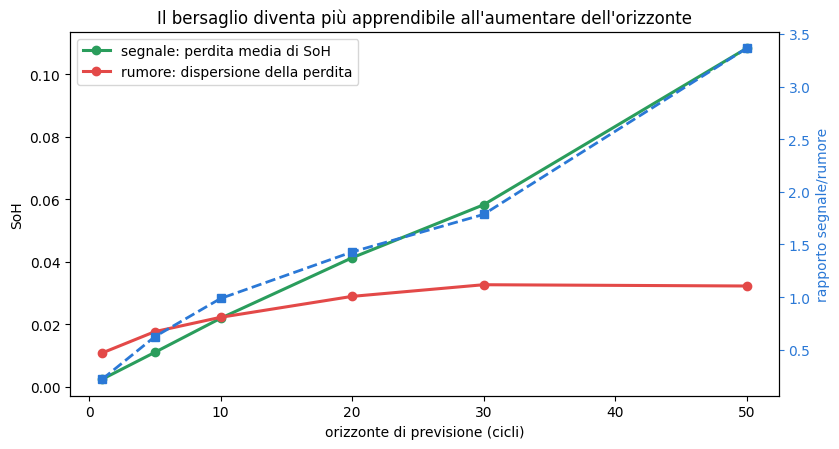

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))

ax.plot(segnale.orizzonte, segnale.segnale, "-o", color="#2a9d5c", lw=2.2,
        label="segnale: perdita media di SoH")
ax.plot(segnale.orizzonte, segnale.rumore, "-o", color="#e34948", lw=2.2,
        label="rumore: dispersione della perdita")
ax.set_xlabel("orizzonte di previsione (cicli)")
ax.set_ylabel("SoH")
ax.legend(loc="upper left")

secondo = ax.twinx()
secondo.plot(segnale.orizzonte, segnale.rapporto, "--s", color="#2a78d6", lw=2)
secondo.set_ylabel("rapporto segnale/rumore", color="#2a78d6")
secondo.tick_params(axis="y", colors="#2a78d6")

ax.set_title("Il bersaglio diventa più apprendibile all'aumentare dell'orizzonte")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_orizzonte_segnale_rumore.png", dpi=200, bbox_inches="tight")
plt.show()


In [13]:
sotto = pareggio[(pareggio.insieme == "test_id") & (pareggio.modello == ARCHITETTURA)]
primo = sotto.primo_orizzonte_vincente.iloc[0]

print("Conclusione dell'esperimento\n")
if pd.notna(primo):
    riga_base = riepilogo[(riepilogo.insieme == "test_id")
                          & (riepilogo.modello == "Baseline persistenza")
                          & (riepilogo.orizzonte == primo)].iloc[0]
    riga_modello = riepilogo[(riepilogo.insieme == "test_id")
                             & (riepilogo.modello == ARCHITETTURA)
                             & (riepilogo.orizzonte == primo)].iloc[0]
    print(f"Sul test in distribuzione il {ARCHITETTURA} supera la persistenza a partire "
          f"dall'orizzonte di {int(primo)} cicli:")
    print(f"  persistenza  RMSE {riga_base.RMSE:.5f}")
    print(f"  {ARCHITETTURA:11s}  RMSE {riga_modello.RMSE:.5f}   "
          f"skill score {riga_modello.SS:+.3f}")
    print()
    print("Il risultato negativo della domanda 1 non dipende quindi dai modelli ma")
    print("dall'orizzonte: a un ciclo di distanza il bersaglio è dominato dal rumore di")
    print("misura, e nessun metodo può estrarne più di quanto ne contenga.")
else:
    print(f"Su nessuno degli orizzonti provati il {ARCHITETTURA} supera la persistenza.")
    print("L'ipotesi non è confermata su questo intervallo: o il passaggio avviene oltre")
    print(f"i {max(ORIZZONTI_UTILI)} cicli, dove le finestre disponibili non bastano, o")
    print("la quantità di dati di addestramento è il vincolo dominante.")

print()
print("Limite dell'esperimento: allungando l'orizzonte il numero di finestre cala")
print(f"({disponibilita.set_index('orizzonte').loc[ORIZZONTI_UTILI[0], 'test_id']} a "
      f"orizzonte {ORIZZONTI_UTILI[0]}, "
      f"{disponibilita.set_index('orizzonte').loc[ORIZZONTI_UTILI[-1], 'test_id']} a "
      f"orizzonte {ORIZZONTI_UTILI[-1]}), quindi le stime a orizzonte lungo sono meno")
print("precise. È una conseguenza inevitabile della lunghezza delle serie disponibili.")


Conclusione dell'esperimento

Sul test in distribuzione il GRU supera la persistenza a partire dall'orizzonte di 10 cicli:
  persistenza  RMSE 0.03114
  GRU          RMSE 0.02858   skill score +0.157

Il risultato negativo della domanda 1 non dipende quindi dai modelli ma
dall'orizzonte: a un ciclo di distanza il bersaglio è dominato dal rumore di
misura, e nessun metodo può estrarne più di quanto ne contenga.

Limite dell'esperimento: allungando l'orizzonte il numero di finestre cala
(172 a orizzonte 1, 73 a orizzonte 50), quindi le stime a orizzonte lungo sono meno
precise. È una conseguenza inevitabile della lunghezza delle serie disponibili.
